<a href="https://colab.research.google.com/github/SAMYSOSERIOUS/CS2_Knee_Xray/blob/test/ko_week1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automated KOA Severity Grading: Benchmarking ResNet50 vs. DenseNet121

**Student:** Sami Hamrouni  
**Supervisor:** Prof. Dr.-Ing. Binh Vu  
**Course:** Case Study 2: X-Ray – Public Datasets  
**Date:** [Start Date]

## 1.1 Project Objective
This notebook implements a reproducible benchmarking pipeline to compare **ResNet50** and **DenseNet121** for **5-class Kellgren–Lawrence (KL) grading** on the public *Knee Osteoarthritis Severity Grading Dataset*.

## 1.2 State-of-the-Art (SOTA) Context
Recent benchmarks on *this specific dataset* inform our performance expectations and methodology:

- **Highest Reported Performance:** **99% accuracy** using an ensemble of EfficientNet, DenseNet, InceptionV3, and MobileNet (GitHub Thesis, 2023).
- **Strong Hybrid Model:** **98.6% accuracy** achieved by an **Autoencoder + Extreme Learning Machine (ELM)** (Peer-reviewed study, 2025).
- **Key Insight:** SOTA emphasizes **ensembles** and **data-centric optimization**. While this work focuses on single-model benchmarking, the use of **CLAHE** and **class-weighted loss** aligns with modern SOTA pipelines.


In [ ]:
# ====================
# SECTION 2: ENVIRONMENT SETUP & REPRODUCIBILITY
# ====================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')

# ----- Absolute Reproducibility -----
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"Libraries imported. Random seed set to {SEED} for reproducibility.")
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


Libraries imported. Random seed set to 42 for reproducibility.
TensorFlow version: 2.19.0
GPU available: []


**Description:** This code cell sets up the computational environment by importing all necessary libraries for the project, including data processing (NumPy, pandas), visualization (matplotlib, seaborn), image processing (OpenCV), machine learning (scikit-learn), and deep learning (TensorFlow). It also establishes reproducibility by setting a fixed random seed (42) across all random number generators to ensure consistent results across runs. The cell verifies the TensorFlow version and checks for GPU availability.

In [ ]:
# ====================
# DATASET DOWNLOAD
# ====================
import kagglehub

# Download latest version
dataset_base_path = kagglehub.dataset_download("shashwatwork/knee-osteoarthritis-dataset-with-severity")

print("Path to dataset files:", dataset_base_path)
print("Dataset downloaded successfully!")

100%|██████████| 204M/204M [00:05<00:00, 39.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/versions/1
Dataset downloaded successfully!


**Description:** This code cell downloads the Knee Osteoarthritis dataset directly from Kaggle using the kagglehub library. It downloads the latest version of the dataset "shashwatwork/knee-osteoarthritis-dataset-with-severity" and stores the path to the downloaded files. This ensures the dataset is automatically fetched when running the notebook in Google Colab or any environment with kagglehub installed.

## 3. Data Exploration

### 3.1 Dataset Structure & Class Distribution
The dataset is organized by **KL grade (0–4)**. We first analyze the class distribution to understand the inherent imbalance, a common challenge in medical imaging datasets.


In [ ]:
# ====================
# DATASET STRUCTURE EXPLORATION
# ====================
import os
import kagglehub

# Download latest version
dataset_base_path = kagglehub.dataset_download("shashwatwork/knee-osteoarthritis-dataset-with-severity")

print("Dataset base path:", dataset_base_path)

# First, let's explore the actual structure
print("\nExploring dataset structure:")
print("-" * 50)

# List all items in the base directory
for item in os.listdir(dataset_base_path):
    item_path = os.path.join(dataset_base_path, item)
    if os.path.isdir(item_path):
        print(f"Directory: {item}")
        # List subdirectories
        for subitem in os.listdir(item_path)[:10]:  # Show first 10 items
            subitem_path = os.path.join(item_path, subitem)
            if os.path.isdir(subitem_path):
                print(f"  - Subdirectory: {subitem}")
            else:
                print(f"  - File: {subitem}")
    else:
        print(f"File: {item}")

print("-" * 50)

Using Colab cache for faster access to the 'knee-osteoarthritis-dataset-with-severity' dataset.
Dataset base path: /kaggle/input/knee-osteoarthritis-dataset-with-severity

Exploring dataset structure:
--------------------------------------------------
Directory: auto_test
  - Subdirectory: 2
  - Subdirectory: 0
  - Subdirectory: 3
  - Subdirectory: 1
  - Subdirectory: 4
Directory: val
  - Subdirectory: 2
  - Subdirectory: 0
  - Subdirectory: 3
  - Subdirectory: 1
  - Subdirectory: 4
Directory: test
  - Subdirectory: 2
  - Subdirectory: 0
  - Subdirectory: 3
  - Subdirectory: 1
  - Subdirectory: 4
Directory: train
  - Subdirectory: 2
  - Subdirectory: 0
  - Subdirectory: 3
  - Subdirectory: 1
  - Subdirectory: 4
--------------------------------------------------


Base path: /kaggle/input/knee-osteoarthritis-dataset-with-severity
Path exists: True

Contents of base directory:
  - auto_test
  - val
  - test
  - train

Processing train split...

Processing val split...

Processing test split...

Processing auto_test split...

Total images loaded: 9786

Distribution by split:
split
train        5778
test         1656
auto_test    1526
val           826
Name: count, dtype: int64

Distribution by KL grade (overall):
kl_grade
0    3857
1    1770
2    2578
3    1286
4     295
Name: count, dtype: int64


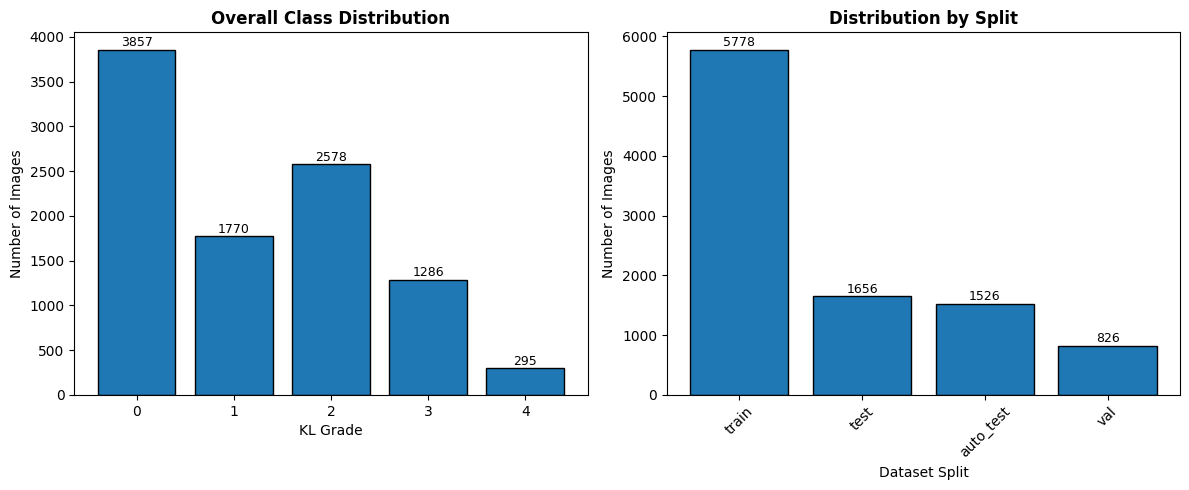

<Figure size 640x480 with 0 Axes>

In [ ]:
# ====================
# PROPER DATASET LOADING
# ====================

import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# Define the base path (from your output)
base_path = "/kaggle/input/knee-osteoarthritis-dataset-with-severity"

print(f"Base path: {base_path}")
print(f"Path exists: {os.path.exists(base_path)}")

# List what's in the base directory
print("\nContents of base directory:")
for item in os.listdir(base_path):
    print(f"  - {item}")

# Now load the data properly
splits = ['train', 'val', 'test', 'auto_test']
all_data = []

for split in splits:
    split_path = os.path.join(base_path, split)
    if os.path.exists(split_path):
        print(f"\nProcessing {split} split...")
        for grade in range(5):
            grade_path = os.path.join(split_path, str(grade))
            if os.path.exists(grade_path):
                for img_name in os.listdir(grade_path):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        img_path = os.path.join(grade_path, img_name)
                        all_data.append({
                            'image_path': img_path,
                            'kl_grade': grade,
                            'split': split
                        })

# Create DataFrame
df = pd.DataFrame(all_data)

print(f"\nTotal images loaded: {len(df)}")
if len(df) > 0:
    print(f"\nDistribution by split:")
    print(df['split'].value_counts())

    print(f"\nDistribution by KL grade (overall):")
    print(df['kl_grade'].value_counts().sort_index())

    # Visualize the distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot 1: Overall class distribution
    ax1 = axes[0]
    distribution = df['kl_grade'].value_counts().sort_index()
    bars = ax1.bar(distribution.index, distribution.values, edgecolor='black')
    ax1.set_title('Overall Class Distribution', fontsize=12, fontweight='bold')
    ax1.set_xlabel('KL Grade')
    ax1.set_ylabel('Number of Images')
    ax1.set_xticks(distribution.index)

    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

    # Plot 2: Distribution by split
    ax2 = axes[1]
    split_counts = df['split'].value_counts()
    bars2 = ax2.bar(split_counts.index, split_counts.values, edgecolor='black')
    ax2.set_title('Distribution by Split', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Dataset Split')
    ax2.set_ylabel('Number of Images')
    ax2.set_xticks(range(len(split_counts)))
    ax2.set_xticklabels(split_counts.index, rotation=45)

    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()



    plt.tight_layout()
    plt.show()

else:
    print("ERROR: No images loaded!")
    print("\nTrying alternative loading method...")

    # Try alternative approach
    all_images = []
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_images.append(os.path.join(root, file))

    print(f"Found {len(all_images)} image files")
    if len(all_images) > 0:
        print("First 10 image paths:")
        for path in all_images[:10]:
            print(f"  - {path}")

### 3.2 Visualizing Sample Images
Random samples from each KL grade are shown to inspect visual characteristics and grading difficulty.


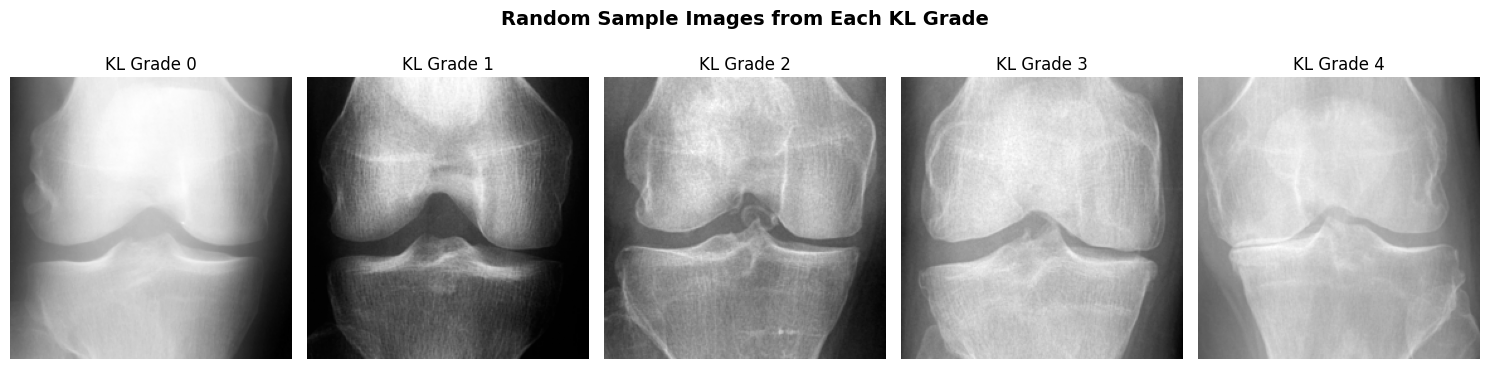

In [ ]:
# ----- Visualization: Sample Images -----
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
fig.suptitle('Random Sample Images from Each KL Grade', fontsize=14, fontweight='bold')

for grade in range(5):
    sample_path = df[df['kl_grade'] == grade].sample(1)['image_path'].values[0]
    img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
    axes[grade].imshow(img, cmap='gray')
    axes[grade].set_title(f'KL Grade {grade}')
    axes[grade].axis('off')

plt.tight_layout()
plt.show()


**Description:** This markdown cell introduces the visualization of sample images from each KL grade. It explains that showing random samples helps understand the visual characteristics and difficulty of grading between different severity levels.

## 4. Preprocessing Pipeline

### 4.1 Contrast Enhancement with CLAHE
CLAHE is applied to improve local contrast in knee X-ray images, enhancing subtle structural details relevant for KL grading.


**Description:** This markdown cell introduces Section 4: Preprocessing Pipeline. It specifically discusses the use of CLAHE (Contrast Limited Adaptive Histogram Equalization) for contrast enhancement in knee X-ray images, explaining that this technique helps reveal subtle structural details important for accurate KL grading.

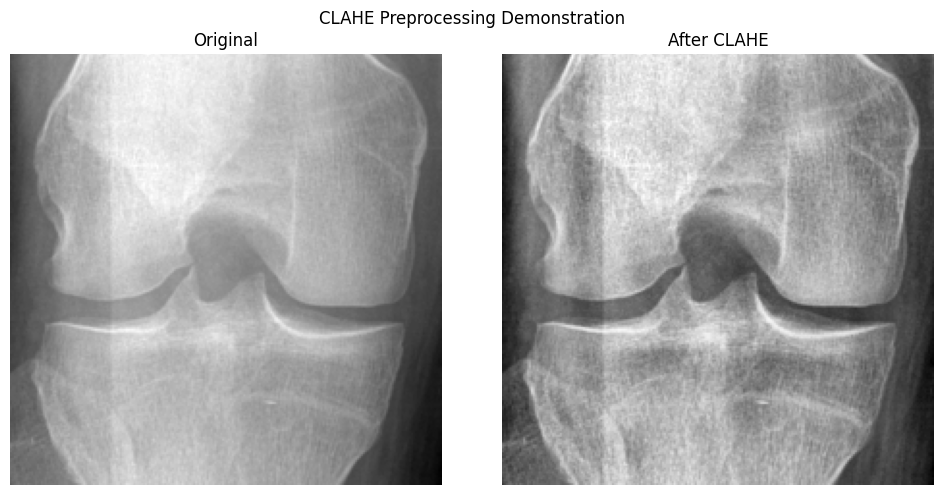

In [ ]:
# ====================
# SECTION 4: PREPROCESSING PIPELINE
# ====================

def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(image)

# ----- Demonstrate CLAHE -----
sample_img_path = df[df['kl_grade'] == 2].sample(1)['image_path'].values[0]
original_img = cv2.imread(sample_img_path, cv2.IMREAD_GRAYSCALE)
clahe_img = apply_clahe(original_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(clahe_img, cmap='gray')
axes[1].set_title('After CLAHE')
axes[1].axis('off')

plt.suptitle('CLAHE Preprocessing Demonstration')
plt.tight_layout()
plt.show()


**Description:** This code cell:
1. Defines a function `apply_clahe()` that applies Contrast Limited Adaptive Histogram Equalization to an image
2. Demonstrates the CLAHE preprocessing by selecting a random sample image (KL grade 2)
3. Shows a side-by-side comparison of the original image and the CLAHE-enhanced image

CLAHE is particularly useful for medical images as it enhances local contrast while limiting noise amplification, making subtle features more visible without over-enhancing noise.

In [ ]:
# ----- Compute Class Weights -----
class_weights_list = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df['kl_grade']),
    y=df['kl_grade']
)

class_weights = {i: class_weights_list[i] for i in range(5)}
print("Computed Class Weights:")
for k, v in class_weights.items():
    print(f"KL Grade {k}: {v:.3f}")


Computed Class Weights:
KL Grade 0: 0.507
KL Grade 1: 1.106
KL Grade 2: 0.759
KL Grade 3: 1.522
KL Grade 4: 6.635


**Description:** This code cell addresses the class imbalance identified in Section 3. It:
1. Computes class weights using scikit-learn's `compute_class_weight` function with the 'balanced' strategy
2. Creates a dictionary mapping each class (KL grade 0-4) to its computed weight
3. Prints the class weights

These weights will be used during model training to give more importance to underrepresented classes, helping the model learn from all classes effectively despite the imbalance.

In [ ]:
# ----- Preprocessing Function -----
TARGET_SIZE = (224, 224)

def preprocess_image(image_path, apply_augmentation=False, use_clahe=True):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if use_clahe:
        img = apply_clahe(img)

    img = cv2.resize(img, TARGET_SIZE)
    img = cv2.merge([img, img, img])
    img = img.astype('float32') / 255.0

    if apply_augmentation and np.random.rand() > 0.5:
        img = cv2.flip(img, 1)

    return img

test_img = preprocess_image(sample_img_path)
print("Preprocessed image shape:", test_img.shape)
print("Pixel range:", test_img.min(), test_img.max())

print("\nNOTEBOOK SECTIONS 1–4 COMPLETED.")


Preprocessed image shape: (224, 224, 3)
Pixel range: 0.21960784 0.8862745

NOTEBOOK SECTIONS 1–4 COMPLETED.


**Description:** This code cell defines the complete preprocessing pipeline function and tests it. The `preprocess_image()` function:
1. Loads an image in grayscale
2. Applies CLAHE contrast enhancement (optional)
3. Resizes the image to 224×224 pixels (standard size for ResNet/DenseNet)
4. Converts the single-channel grayscale image to 3 channels (required by pretrained models)
5. Normalizes pixel values to [0, 1] range
6. Optionally applies data augmentation (horizontal flipping with 50% probability)

